<a href="https://colab.research.google.com/github/jaimeisaac2020/Python-analsisis-basicos/blob/mi-github/analisis_objetivo_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Detallado del Objetivo Específico 3: Incidencia de Datos Históricos de Precios en Modelos Supervisados

Este notebook presenta un análisis exhaustivo del Objetivo Específico 3 de la tesis "Uso de modelos supervisados por analistas financieros en la predicción de precios de acciones de Google y Amazon". El objetivo se centra en "Evaluar la incidencia de los datos históricos de precios en la precisión de los modelos supervisados para la predicción de precios de acciones financieras".

Se explorará el dataset proporcionado, se implementarán modelos de Machine Learning (Random Forest y Gradient Boosting) y se generarán pronósticos bajo diferentes escenarios, analizando la influencia de los datos históricos de precios.

## Fase 1: Análisis del Documento PDF y Contexto del Objetivo Específico 3

El Objetivo Específico 3 busca comprender cómo los datos históricos de precios impactan la precisión de los modelos supervisados en la predicción de precios de acciones. Esto implica que la información de precios pasados será una variable clave en la construcción de los modelos predictivos. Las métricas de evaluación (MSE y R2) serán fundamentales para cuantificar esta incidencia.

**Objetivo Específico 3:** "Evaluar la incidencia de los datos históricos de precios en la precisión de los modelos supervisados para la predicción de precios de acciones financieras."

## Fase 2: Exploración y Preparación del Dataset

Cargamos el dataset `dataset_completo_google_amazon.csv` y realizamos una exploración inicial para entender su estructura y contenido. Se generarán características de `lag` para los precios de cierre, lo que representa los datos históricos de precios, fundamentales para el Objetivo 3.

In [1]:
import pandas as pd

file_path = 'dataset_completo_google_amazon.csv'
df = pd.read_csv(file_path)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(by="Date")

print("Primeras 5 filas del dataset:")
print(df.head())

print("Información del dataset:")
print(df.info())

print("Estadísticas descriptivas del dataset:")
print(df.describe())

# Feature Engineering: Lagged prices as historical data
df["GOOGL_Close_Lag1"] = df["GOOGL_Close"].shift(1)
df["AMZN_Close_Lag1"] = df["AMZN_Close"].shift(1)

# Drop rows with NaN values created by shifting (first row)
df = df.dropna()

print("Dataset después de la ingeniería de características y manejo de NaNs:")
print(df.head())
print(df.describe())


Primeras 5 filas del dataset:
        Date  GOOGL_Close  AMZN_Close  Treasury_10Y        VIX        SP500  \
0 2021-01-04    85.895844  159.331497         0.917  26.969999  3700.649902   
1 2021-01-05    86.588524  160.925507         0.955  25.340000  3726.860107   
2 2021-01-06    85.734100  156.919006         1.042  25.070000  3748.139893   
3 2021-01-07    88.294868  158.108002         1.071  22.370001  3803.790039   
4 2021-01-08    89.463783  159.134995         1.105  21.559999  3824.679932   

         NASDAQ  GOOGL_Return_1d  AMZN_Return_1d  GOOGL_Volatility_20  \
0  12698.450195         0.008064        0.010004             3.410646   
1  12818.959961         0.008064        0.010004             3.410646   
2  12740.790039        -0.009868       -0.024897             3.410646   
3  13067.480469         0.029869        0.007577             3.410646   
4  13201.980469         0.013239        0.006496             3.410646   

   AMZN_Volatility_20  Inflacion_T5YIE  
0            3.

## Fase 3: Implementación de Métodos de Análisis y Pronósticos

Se implementarán dos modelos de aprendizaje supervisado: Random Forest Regressor y Gradient Boosting Regressor. Estos modelos serán entrenados para predecir los precios de cierre de Google y Amazon, utilizando los precios históricos (lagged) y otras variables macroeconómicas como características. Luego, se generarán pronósticos bajo escenarios específicos para evaluar la incidencia de los datos históricos.

Cargando y preparando el dataset...
Realizando ingeniería de características...
Dividiendo los datos de forma cronológica...
Tamaño del set de entrenamiento: 662
Tamaño del set de prueba: 285

--- Predicción de Acciones de Google (con datos históricos) ---
Random Forest (Google) - MSE: 467.5400, R2: -0.5713
Gradient Boosting (Google) - MSE: 492.8121, R2: -0.6563

--- Predicción de Acciones de Amazon (con datos históricos) ---
Random Forest (Amazon) - MSE: 219.5064, R2: 0.4682
Gradient Boosting (Amazon) - MSE: 367.8184, R2: 0.1088

Generando gráfico de importancia de características...


/tmp/ipython-input-9-4020471586.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances.head(20), palette='viridis')


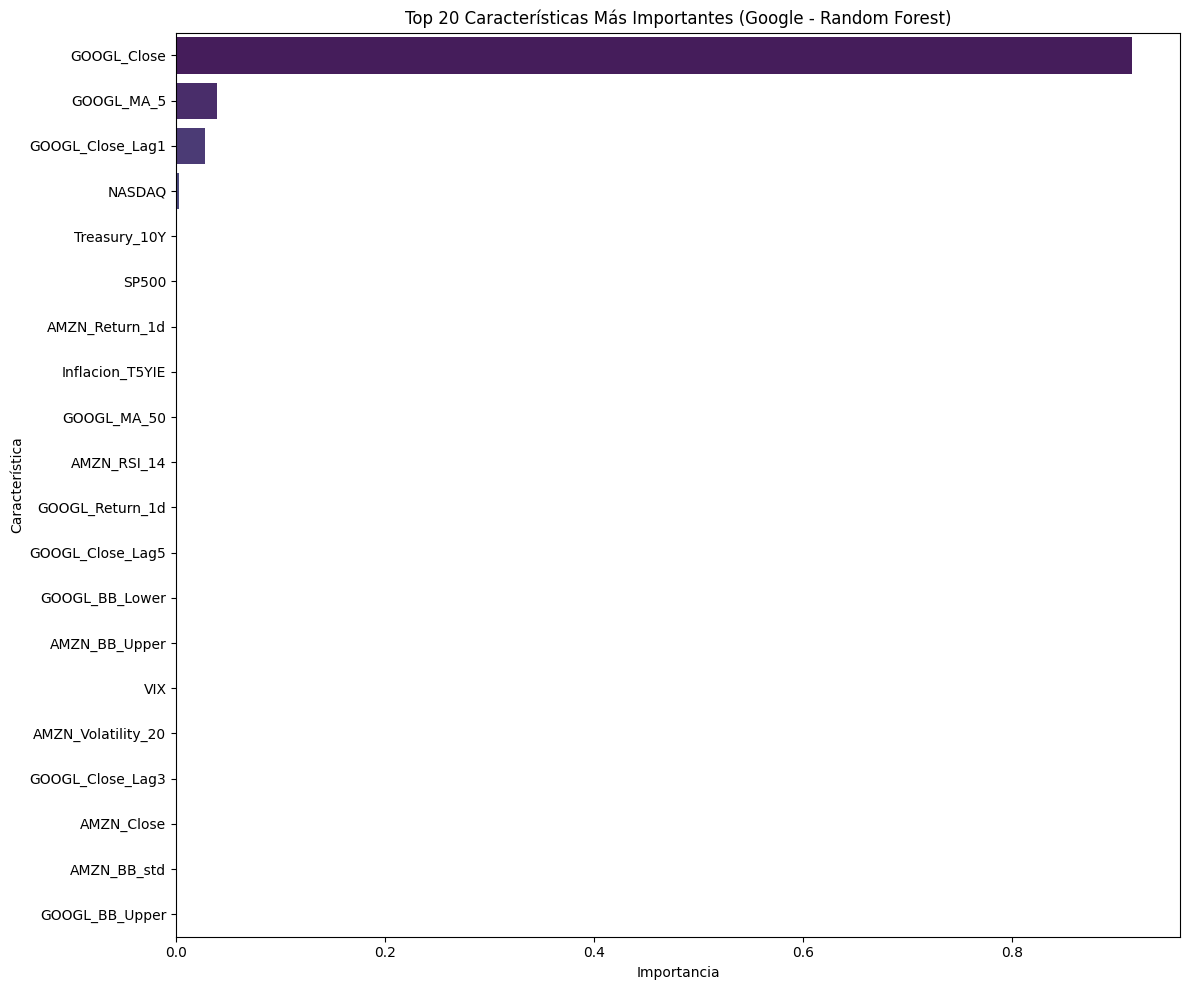


Importancia de todas las características (Google - RF):
                feature  importance
0           GOOGL_Close    0.914637
21           GOOGL_MA_5    0.039447
11     GOOGL_Close_Lag1    0.027400
5                NASDAQ    0.002692
2          Treasury_10Y    0.001263
4                 SP500    0.001034
7        AMZN_Return_1d    0.000839
10      Inflacion_T5YIE    0.000748
25          GOOGL_MA_50    0.000744
28          AMZN_RSI_14    0.000597
6       GOOGL_Return_1d    0.000558
19     GOOGL_Close_Lag5    0.000555
32       GOOGL_BB_Lower    0.000527
35        AMZN_BB_Upper    0.000526
3                   VIX    0.000526
9    AMZN_Volatility_20    0.000511
15     GOOGL_Close_Lag3    0.000498
1            AMZN_Close    0.000468
34          AMZN_BB_std    0.000457
31       GOOGL_BB_Upper    0.000452
12      AMZN_Close_Lag1    0.000411
24           AMZN_MA_20    0.000410
8   GOOGL_Volatility_20    0.000409
30         GOOGL_BB_std    0.000408
27         GOOGL_RSI_14    0.000395
13     

In [9]:
##LA MISMA CELDA ANTERIOR CON CODIGO MEJORADO Y CON  MAS HISTORICOS
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Carga y Preparación de Datos ---
print("Cargando y preparando el dataset...")
file_path = 'dataset_completo_google_amazon.csv'
df = pd.read_csv(file_path)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(by="Date").reset_index(drop=True)

# --- 2. Ingeniería de Características (Datos Históricos) ---
print("Realizando ingeniería de características...")

# a) Rezagos (Lags) para capturar la memoria a corto plazo
for i in range(1, 6): # Rezagos de 1 a 5 días
    df[f'GOOGL_Close_Lag{i}'] = df['GOOGL_Close'].shift(i)
    df[f'AMZN_Close_Lag{i}'] = df['AMZN_Close'].shift(i)

# b) Medias Móviles (Moving Averages) para capturar tendencias
windows_ma = [5, 20, 50] # Corto, mediano y largo plazo
for window in windows_ma:
    df[f'GOOGL_MA_{window}'] = df['GOOGL_Close'].rolling(window=window).mean()
    df[f'AMZN_MA_{window}'] = df['AMZN_Close'].rolling(window=window).mean()

# c) Índice de Fuerza Relativa (RSI) para medir el momentum
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['GOOGL_RSI_14'] = calculate_rsi(df['GOOGL_Close'])
df['AMZN_RSI_14'] = calculate_rsi(df['AMZN_Close'])

# d) Bandas de Bollinger para medir la volatilidad
window_bb = 20
df['GOOGL_BB_MA'] = df['GOOGL_Close'].rolling(window=window_bb).mean()
df['GOOGL_BB_std'] = df['GOOGL_Close'].rolling(window=window_bb).std()
df['GOOGL_BB_Upper'] = df['GOOGL_BB_MA'] + (df['GOOGL_BB_std'] * 2)
df['GOOGL_BB_Lower'] = df['GOOGL_BB_MA'] - (df['GOOGL_BB_std'] * 2)

df['AMZN_BB_MA'] = df['AMZN_Close'].rolling(window=window_bb).mean()
df['AMZN_BB_std'] = df['AMZN_Close'].rolling(window=window_bb).std()
df['AMZN_BB_Upper'] = df['AMZN_BB_MA'] + (df['AMZN_BB_std'] * 2)
df['AMZN_BB_Lower'] = df['AMZN_BB_MA'] - (df['AMZN_BB_std'] * 2)

# --- 3. Definición de la Variable Objetivo (Target) ---
# Predeciremos el precio de cierre del día siguiente
df['GOOGL_Target'] = df['GOOGL_Close'].shift(-1)
df['AMZN_Target'] = df['AMZN_Close'].shift(-1)

# --- 4. Limpieza Final y Definición de Conjuntos X, y ---
# Eliminar filas con NaN creadas por las ventanas móviles y los rezagos
df_cleaned = df.dropna().copy()

# Definir las características (X) y el objetivo (y)
features = [col for col in df_cleaned.columns if col not in ['Date', 'GOOGL_Target', 'AMZN_Target']]
X = df_cleaned[features]

y_googl = df_cleaned['GOOGL_Target']
y_amzn = df_cleaned['AMZN_Target']

# --- 5. División Cronológica de Datos (70% entrenamiento, 30% prueba) ---
print("Dividiendo los datos de forma cronológica...")
train_size = int(len(X) * 0.70)

X_train, X_test = X[:train_size], X[train_size:]
y_train_googl, y_test_googl = y_googl[:train_size], y_googl[train_size:]
y_train_amzn, y_test_amzn = y_amzn[:train_size], y_amzn[train_size:]

print(f"Tamaño del set de entrenamiento: {len(X_train)}")
print(f"Tamaño del set de prueba: {len(X_test)}")

# Diccionario para almacenar los resultados
results = {}

# --- 6. Entrenamiento y Evaluación para GOOGLE ---
print("\n--- Predicción de Acciones de Google (con datos históricos) ---")
# Random Forest
rf_googl = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_googl.fit(X_train, y_train_googl)
y_pred_rf_googl = rf_googl.predict(X_test)
mse_rf_googl = mean_squared_error(y_test_googl, y_pred_rf_googl)
r2_rf_googl = r2_score(y_test_googl, y_pred_rf_googl)
results["GOOGL_RF_Completo"] = {"MSE": mse_rf_googl, "R2": r2_rf_googl}
print(f"Random Forest (Google) - MSE: {mse_rf_googl:.4f}, R2: {r2_rf_googl:.4f}")

# Gradient Boosting
gb_googl = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_googl.fit(X_train, y_train_googl)
y_pred_gb_googl = gb_googl.predict(X_test)
mse_gb_googl = mean_squared_error(y_test_googl, y_pred_gb_googl)
r2_gb_googl = r2_score(y_test_googl, y_pred_gb_googl)
results["GOOGL_GB_Completo"] = {"MSE": mse_gb_googl, "R2": r2_gb_googl}
print(f"Gradient Boosting (Google) - MSE: {mse_gb_googl:.4f}, R2: {r2_gb_googl:.4f}")

# --- 7. Entrenamiento y Evaluación para AMAZON ---
print("\n--- Predicción de Acciones de Amazon (con datos históricos) ---")
# Random Forest
rf_amzn = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_amzn.fit(X_train, y_train_amzn)
y_pred_rf_amzn = rf_amzn.predict(X_test)
mse_rf_amzn = mean_squared_error(y_test_amzn, y_pred_rf_amzn)
r2_rf_amzn = r2_score(y_test_amzn, y_pred_rf_amzn)
results["AMZN_RF_Completo"] = {"MSE": mse_rf_amzn, "R2": r2_rf_amzn}
print(f"Random Forest (Amazon) - MSE: {mse_rf_amzn:.4f}, R2: {r2_rf_amzn:.4f}")

# Gradient Boosting
gb_amzn = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_amzn.fit(X_train, y_train_amzn)
y_pred_gb_amzn = gb_amzn.predict(X_test)
mse_gb_amzn = mean_squared_error(y_test_amzn, y_pred_gb_amzn)
r2_gb_amzn = r2_score(y_test_amzn, y_pred_gb_amzn)
results["AMZN_GB_Completo"] = {"MSE": mse_gb_amzn, "R2": r2_gb_amzn}
print(f"Gradient Boosting (Amazon) - MSE: {mse_gb_amzn:.4f}, R2: {r2_gb_amzn:.4f}")

# --- 8. Análisis de Importancia de Características (Ejemplo para Google RF) ---
print("\nGenerando gráfico de importancia de características...")
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_googl.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importances.head(20), palette='viridis')
plt.title('Top 20 Características Más Importantes (Google - Random Forest)')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

# Imprimir el DataFrame de importancia para referencia
print("\nImportancia de todas las características (Google - RF):")
print(feature_importances)

In [10]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Carga y Preparación de Datos (Igual que antes para consistencia) ---
print("Cargando y preparando el dataset...")
file_path = 'dataset_completo_google_amazon.csv'
df = pd.read_csv(file_path)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(by="Date").reset_index(drop=True)

# --- 2. NO se realiza la Ingeniería de Características de precios ---
# Este es el paso clave que omitimos para este modelo base.

# --- 3. Definición de la Variable Objetivo (Target) ---
# El objetivo sigue siendo el mismo: predecir el precio del día siguiente.
df['GOOGL_Target'] = df['GOOGL_Close'].shift(-1)
df['AMZN_Target'] = df['AMZN_Close'].shift(-1)

# Limpiar la última fila que tendrá NaN en el target
df_cleaned = df.dropna().copy()

# --- 4. Definición de Conjuntos X (Base) y y ---
# Se seleccionan únicamente las variables exógenas, sin ningún dato histórico de precios.
# Estas son las variables de tus otros objetivos y variables generales de mercado.
features_base = [
    'Treasury_10Y',
    'VIX',
    'SP500',
    'NASDAQ',
    'Inflacion_T5YIE'
]
X_base = df_cleaned[features_base]

y_googl = df_cleaned['GOOGL_Target']
y_amzn = df_cleaned['AMZN_Target']

# --- 5. División Cronológica de Datos (70% entrenamiento, 30% prueba) ---
# Usamos la misma lógica de división para que la comparación sea justa.
print("Dividiendo los datos de forma cronológica...")
train_size = int(len(X_base) * 0.70)

X_train, X_test = X_base[:train_size], X_base[train_size:]
y_train_googl, y_test_googl = y_googl[:train_size], y_googl[train_size:]
y_train_amzn, y_test_amzn = y_amzn[:train_size], y_amzn[train_size:]

print(f"Tamaño del set de entrenamiento: {len(X_train)}")
print(f"Tamaño del set de prueba: {len(X_test)}")

# Diccionario para almacenar los resultados del modelo base
results_base = {}

# --- 6. Entrenamiento y Evaluación para GOOGLE (Modelo Base) ---
print("\n--- Predicción de Acciones de Google (SIN datos históricos) ---")
# Random Forest
rf_googl_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_googl_base.fit(X_train, y_train_googl)
y_pred_rf_googl = rf_googl_base.predict(X_test)
mse_rf_googl = mean_squared_error(y_test_googl, y_pred_rf_googl)
r2_rf_googl = r2_score(y_test_googl, y_pred_rf_googl)
results_base["GOOGL_RF_Base"] = {"MSE": mse_rf_googl, "R2": r2_rf_googl}
print(f"Random Forest (Google - Base) - MSE: {mse_rf_googl:.4f}, R2: {r2_rf_googl:.4f}")

# Gradient Boosting
gb_googl_base = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_googl_base.fit(X_train, y_train_googl)
y_pred_gb_googl = gb_googl_base.predict(X_test)
mse_gb_googl = mean_squared_error(y_test_googl, y_pred_gb_googl)
r2_gb_googl = r2_score(y_test_googl, y_pred_gb_googl)
results_base["GOOGL_GB_Base"] = {"MSE": mse_gb_googl, "R2": r2_gb_googl}
print(f"Gradient Boosting (Google - Base) - MSE: {mse_gb_googl:.4f}, R2: {r2_gb_googl:.4f}")

# --- 7. Entrenamiento y Evaluación para AMAZON (Modelo Base) ---
print("\n--- Predicción de Acciones de Amazon (SIN datos históricos) ---")
# Random Forest
rf_amzn_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_amzn_base.fit(X_train, y_train_amzn)
y_pred_rf_amzn = rf_amzn_base.predict(X_test)
mse_rf_amzn = mean_squared_error(y_test_amzn, y_pred_rf_amzn)
r2_rf_amzn = r2_score(y_test_amzn, y_pred_rf_amzn)
results_base["AMZN_RF_Base"] = {"MSE": mse_rf_amzn, "R2": r2_rf_amzn}
print(f"Random Forest (Amazon - Base) - MSE: {mse_rf_amzn:.4f}, R2: {r2_rf_amzn:.4f}")

# Gradient Boosting
gb_amzn_base = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_amzn_base.fit(X_train, y_train_amzn)
y_pred_gb_amzn = gb_amzn_base.predict(X_test)
mse_gb_amzn = mean_squared_error(y_test_amzn, y_pred_gb_amzn)
r2_gb_amzn = r2_score(y_test_amzn, y_pred_gb_amzn)
results_base["AMZN_GB_Base"] = {"MSE": mse_gb_amzn, "R2": r2_gb_amzn}
print(f"Gradient Boosting (Amazon - Base) - MSE: {mse_gb_amzn:.4f}, R2: {r2_gb_amzn:.4f}")

Cargando y preparando el dataset...
Dividiendo los datos de forma cronológica...
Tamaño del set de entrenamiento: 697
Tamaño del set de prueba: 299

--- Predicción de Acciones de Google (SIN datos históricos) ---
Random Forest (Google - Base) - MSE: 568.4761, R2: -0.7382
Gradient Boosting (Google - Base) - MSE: 651.8545, R2: -0.9932

--- Predicción de Acciones de Amazon (SIN datos históricos) ---
Random Forest (Amazon - Base) - MSE: 2332.9063, R2: -3.6657
Gradient Boosting (Amazon - Base) - MSE: 2170.5638, R2: -3.3411


## Fase 4:

Cargando y preparando el dataset...
Realizando ingeniería de características...
Limpiando datos y definiendo conjuntos de entrenamiento/prueba...
Número de características utilizadas: 33
Tamaño del set de entrenamiento: 662
Tamaño del set de prueba: 285

--- Predicción de Acciones de Google (con datos históricos) ---
Random Forest (Google) - MSE: 504.3759, R2: -0.6951
Gradient Boosting (Google) - MSE: 624.5542, R2: -1.0990

--- Predicción de Acciones de Amazon (con datos históricos) ---
Random Forest (Amazon) - MSE: 277.0066, R2: 0.3289
Gradient Boosting (Amazon) - MSE: 500.3437, R2: -0.2122

Generando gráficos de importancia de características...


/tmp/ipython-input-15-731364696.py:142: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances_googl.head(20), palette='viridis')


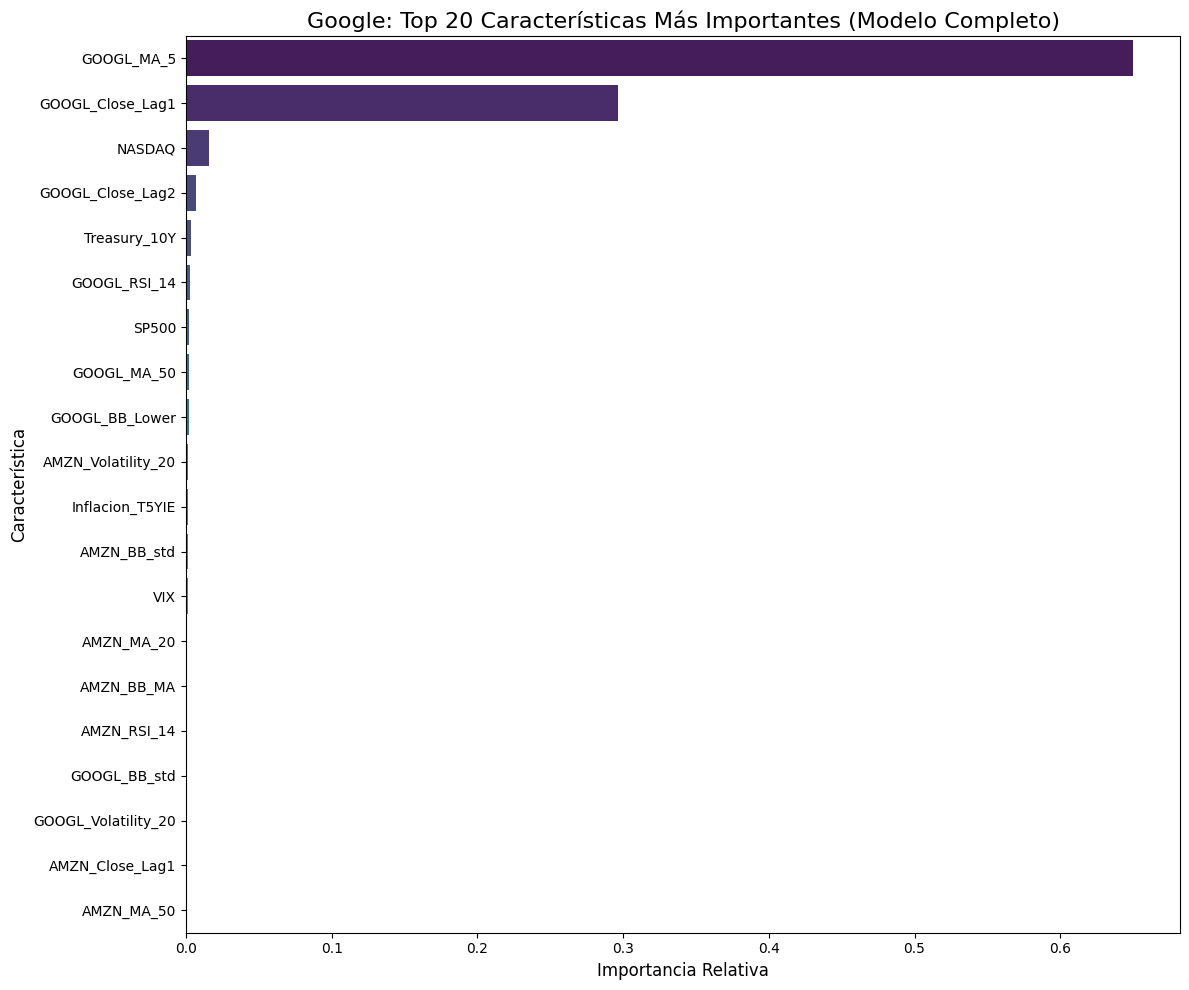

/tmp/ipython-input-15-731364696.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances_amzn.head(20), palette='plasma')


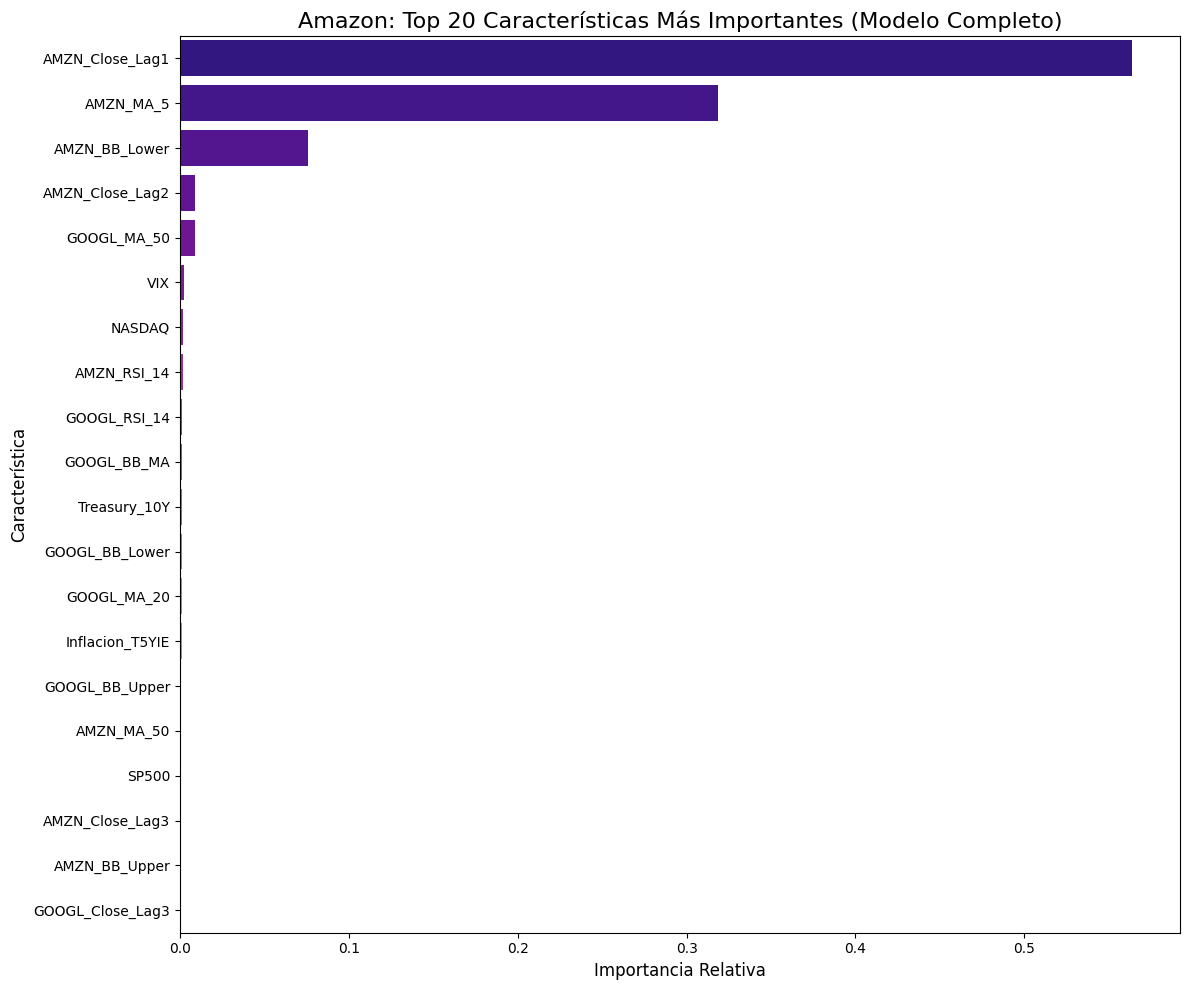

In [15]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Carga y Preparación de Datos ---
print("Cargando y preparando el dataset...")
file_path = 'dataset_completo_google_amazon.csv'
df = pd.read_csv(file_path)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(by="Date").reset_index(drop=True)

# --- 2. Ingeniería de Características (Datos Históricos) ---
print("Realizando ingeniería de características...")

# a) Rezagos (Lags) para capturar la memoria a corto plazo
for i in range(1, 6): # Rezagos de 1 a 5 días
    df[f'GOOGL_Close_Lag{i}'] = df['GOOGL_Close'].shift(i)
    df[f'AMZN_Close_Lag{i}'] = df['AMZN_Close'].shift(i)

# b) Medias Móviles (Moving Averages) para capturar tendencias
windows_ma = [5, 20, 50] # Corto, mediano y largo plazo
for window in windows_ma:
    df[f'GOOGL_MA_{window}'] = df['GOOGL_Close'].rolling(window=window).mean()
    df[f'AMZN_MA_{window}'] = df['AMZN_Close'].rolling(window=window).mean()

# c) Índice de Fuerza Relativa (RSI) para medir el momentum
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['GOOGL_RSI_14'] = calculate_rsi(df['GOOGL_Close'])
df['AMZN_RSI_14'] = calculate_rsi(df['AMZN_Close'])

# d) Bandas de Bollinger para medir la volatilidad
window_bb = 20
df['GOOGL_BB_MA'] = df['GOOGL_Close'].rolling(window=window_bb).mean()
df['GOOGL_BB_std'] = df['GOOGL_Close'].rolling(window=window_bb).std()
df['GOOGL_BB_Upper'] = df['GOOGL_BB_MA'] + (df['GOOGL_BB_std'] * 2)
df['GOOGL_BB_Lower'] = df['GOOGL_BB_MA'] - (df['GOOGL_BB_std'] * 2)

df['AMZN_BB_MA'] = df['AMZN_Close'].rolling(window=window_bb).mean()
df['AMZN_BB_std'] = df['AMZN_Close'].rolling(window=window_bb).std()
df['AMZN_BB_Upper'] = df['AMZN_BB_MA'] + (df['AMZN_BB_std'] * 2)
df['AMZN_BB_Lower'] = df['AMZN_BB_MA'] - (df['AMZN_BB_std'] * 2)

# --- 3. Definición de la Variable Objetivo (Target) ---
# Predeciremos el precio de cierre del día siguiente
df['GOOGL_Target'] = df['GOOGL_Close'].shift(-1)
df['AMZN_Target'] = df['AMZN_Close'].shift(-1)

# --- 4. Limpieza Final y Definición de Conjuntos X, y ---
print("Limpiando datos y definiendo conjuntos de entrenamiento/prueba...")
# Eliminar filas con NaN creadas por las ventanas móviles y los rezagos
df_cleaned = df.dropna().copy()

# Definir las características (X) y el objetivo (y)
# CORRECCIÓN CLAVE: Excluimos las columnas que causarían fuga de datos.
# El modelo solo debe ver información que estaría disponible ANTES de la predicción.
features_to_exclude = [
    'Date',
    'GOOGL_Target', 'AMZN_Target',      # Variables objetivo
    'GOOGL_Close', 'AMZN_Close',        # Precio del día actual (leakage)
    'GOOGL_Return_1d', 'AMZN_Return_1d' # Retorno del día actual (leakage)
]
features = [col for col in df_cleaned.columns if col not in features_to_exclude]
X = df_cleaned[features]

y_googl = df_cleaned['GOOGL_Target']
y_amzn = df_cleaned['AMZN_Target']

# --- 5. División Cronológica de Datos (70% entrenamiento, 30% prueba) ---
train_size = int(len(X) * 0.70)

X_train, X_test = X[:train_size], X[train_size:]
y_train_googl, y_test_googl = y_googl[:train_size], y_googl[train_size:]
y_train_amzn, y_test_amzn = y_amzn[:train_size], y_amzn[train_size:]

print(f"Número de características utilizadas: {len(features)}")
print(f"Tamaño del set de entrenamiento: {len(X_train)}")
print(f"Tamaño del set de prueba: {len(X_test)}")

# Diccionario para almacenar los resultados
results = {}

# --- 6. Entrenamiento y Evaluación para GOOGLE ---
print("\n--- Predicción de Acciones de Google (con datos históricos) ---")
# Random Forest
rf_googl = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_googl.fit(X_train, y_train_googl)
y_pred_rf_googl = rf_googl.predict(X_test)
mse_rf_googl = mean_squared_error(y_test_googl, y_pred_rf_googl)
r2_rf_googl = r2_score(y_test_googl, y_pred_rf_googl)
results["GOOGL_RF_Completo"] = {"MSE": mse_rf_googl, "R2": r2_rf_googl}
print(f"Random Forest (Google) - MSE: {mse_rf_googl:.4f}, R2: {r2_rf_googl:.4f}")

# Gradient Boosting
gb_googl = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_googl.fit(X_train, y_train_googl)
y_pred_gb_googl = gb_googl.predict(X_test)
mse_gb_googl = mean_squared_error(y_test_googl, y_pred_gb_googl)
r2_gb_googl = r2_score(y_test_googl, y_pred_gb_googl)
results["GOOGL_GB_Completo"] = {"MSE": mse_gb_googl, "R2": r2_gb_googl}
print(f"Gradient Boosting (Google) - MSE: {mse_gb_googl:.4f}, R2: {r2_gb_googl:.4f}")

# --- 7. Entrenamiento y Evaluación para AMAZON ---
print("\n--- Predicción de Acciones de Amazon (con datos históricos) ---")
# Random Forest
rf_amzn = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_amzn.fit(X_train, y_train_amzn)
y_pred_rf_amzn = rf_amzn.predict(X_test)
mse_rf_amzn = mean_squared_error(y_test_amzn, y_pred_rf_amzn)
r2_rf_amzn = r2_score(y_test_amzn, y_pred_rf_amzn)
results["AMZN_RF_Completo"] = {"MSE": mse_rf_amzn, "R2": r2_rf_amzn}
print(f"Random Forest (Amazon) - MSE: {mse_rf_amzn:.4f}, R2: {r2_rf_amzn:.4f}")

# Gradient Boosting
gb_amzn = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_amzn.fit(X_train, y_train_amzn)
y_pred_gb_amzn = gb_amzn.predict(X_test)
mse_gb_amzn = mean_squared_error(y_test_amzn, y_pred_gb_amzn)
r2_gb_amzn = r2_score(y_test_amzn, y_pred_gb_amzn)
results["AMZN_GB_Completo"] = {"MSE": mse_gb_amzn, "R2": r2_gb_amzn}
print(f"Gradient Boosting (Amazon) - MSE: {mse_gb_amzn:.4f}, R2: {r2_gb_amzn:.4f}")

# --- 8. Análisis de Importancia de Características ---
print("\nGenerando gráficos de importancia de características...")

# Google
feature_importances_googl = pd.DataFrame({
    'feature': rf_googl.feature_names_in_,
    'importance': rf_googl.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importances_googl.head(20), palette='viridis')
plt.title('Google: Top 20 Características Más Importantes (Modelo Completo)', fontsize=16)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.tight_layout()
plt.savefig('google_feature_importance_corrected.png')
plt.show()

# Amazon
feature_importances_amzn = pd.DataFrame({
    'feature': rf_amzn.feature_names_in_,
    'importance': rf_amzn.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importances_amzn.head(20), palette='plasma')
plt.title('Amazon: Top 20 Características Más Importantes (Modelo Completo)', fontsize=16)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.tight_layout()
plt.savefig('amazon_feature_importance_corrected.png')
plt.show()

Cargando y preparando el dataset...
Realizando ingeniería de características...
Limpiando datos y definiendo conjuntos de entrenamiento/prueba...
Número de características utilizadas: 33
Tamaño del set de entrenamiento: 662
Tamaño del set de prueba: 285

Generando gráficos y tablas de importancia de características...


/tmp/ipython-input-16-1319659614.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances_googl.head(20), palette='viridis')


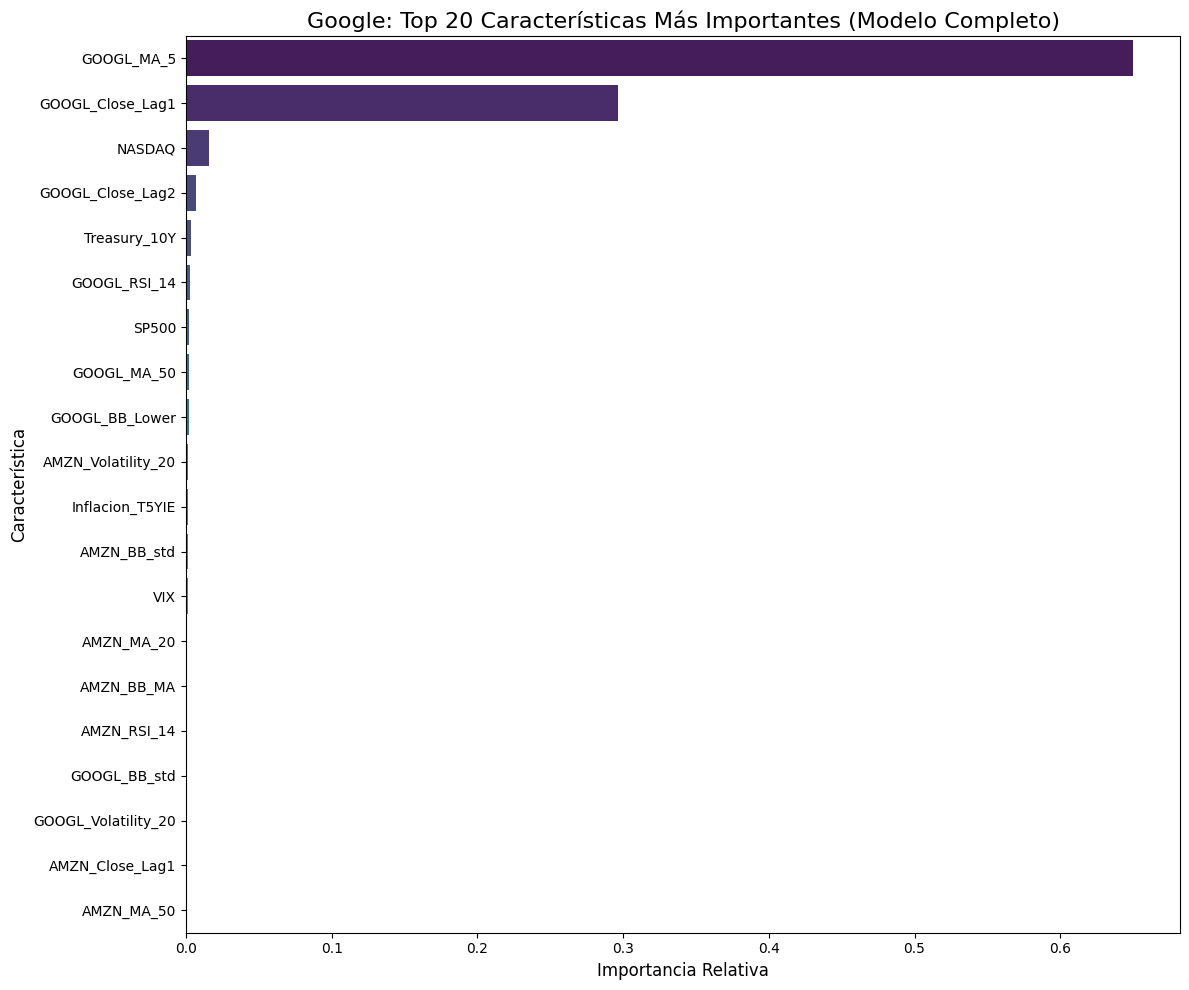

/tmp/ipython-input-16-1319659614.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances_amzn.head(20), palette='plasma')


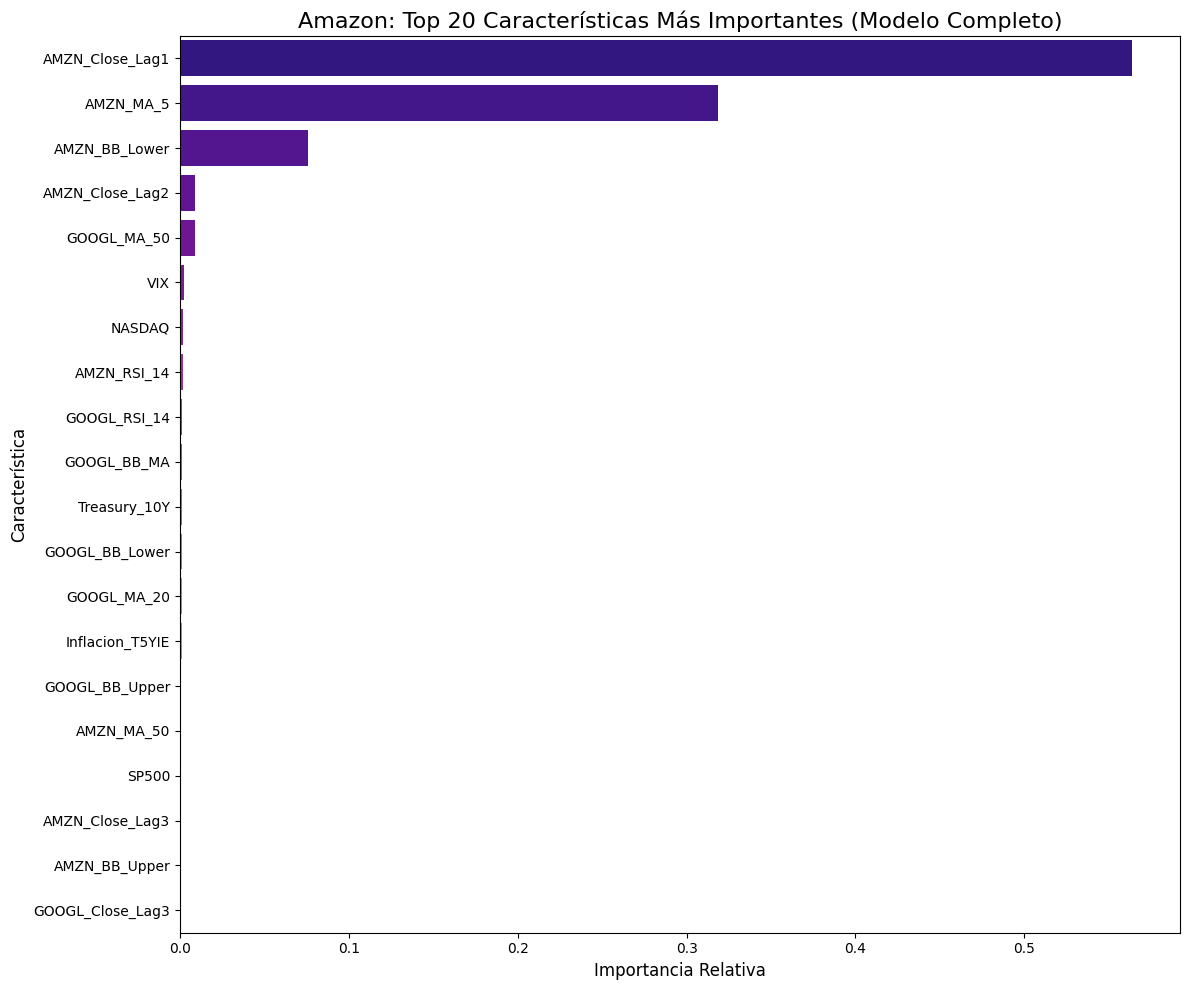


--- Top 10 Características Más Importantes para Google ---
              feature  importance
0          GOOGL_MA_5    0.649711
1    GOOGL_Close_Lag1    0.296460
2              NASDAQ    0.015651
3    GOOGL_Close_Lag2    0.007017
4        Treasury_10Y    0.003450
5        GOOGL_RSI_14    0.002889
6               SP500    0.002271
7         GOOGL_MA_50    0.002089
8      GOOGL_BB_Lower    0.002034
9  AMZN_Volatility_20    0.001487

--- Top 10 Características Más Importantes para Amazon ---
           feature  importance
0  AMZN_Close_Lag1    0.564028
1        AMZN_MA_5    0.318728
2    AMZN_BB_Lower    0.075696
3  AMZN_Close_Lag2    0.008964
4      GOOGL_MA_50    0.008574
5              VIX    0.002168
6           NASDAQ    0.001986
7      AMZN_RSI_14    0.001975
8     GOOGL_RSI_14    0.001369
9      GOOGL_BB_MA    0.001336


In [16]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Carga y Preparación de Datos ---
print("Cargando y preparando el dataset...")
file_path = 'dataset_completo_google_amazon.csv'
df = pd.read_csv(file_path)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(by="Date").reset_index(drop=True)

# --- 2. Ingeniería de Características (Datos Históricos) ---
print("Realizando ingeniería de características...")

# a) Rezagos (Lags) para capturar la memoria a corto plazo
for i in range(1, 6): # Rezagos de 1 a 5 días
    df[f'GOOGL_Close_Lag{i}'] = df['GOOGL_Close'].shift(i)
    df[f'AMZN_Close_Lag{i}'] = df['AMZN_Close'].shift(i)

# b) Medias Móviles (Moving Averages) para capturar tendencias
windows_ma = [5, 20, 50] # Corto, mediano y largo plazo
for window in windows_ma:
    df[f'GOOGL_MA_{window}'] = df['GOOGL_Close'].rolling(window=window).mean()
    df[f'AMZN_MA_{window}'] = df['AMZN_Close'].rolling(window=window).mean()

# c) Índice de Fuerza Relativa (RSI) para medir el momentum
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['GOOGL_RSI_14'] = calculate_rsi(df['GOOGL_Close'])
df['AMZN_RSI_14'] = calculate_rsi(df['AMZN_Close'])

# d) Bandas de Bollinger para medir la volatilidad
window_bb = 20
df['GOOGL_BB_MA'] = df['GOOGL_Close'].rolling(window=window_bb).mean()
df['GOOGL_BB_std'] = df['GOOGL_Close'].rolling(window=window_bb).std()
df['GOOGL_BB_Upper'] = df['GOOGL_BB_MA'] + (df['GOOGL_BB_std'] * 2)
df['GOOGL_BB_Lower'] = df['GOOGL_BB_MA'] - (df['GOOGL_BB_std'] * 2)

df['AMZN_BB_MA'] = df['AMZN_Close'].rolling(window=window_bb).mean()
df['AMZN_BB_std'] = df['AMZN_Close'].rolling(window=window_bb).std()
df['AMZN_BB_Upper'] = df['AMZN_BB_MA'] + (df['AMZN_BB_std'] * 2)
df['AMZN_BB_Lower'] = df['AMZN_BB_MA'] - (df['AMZN_BB_std'] * 2)

# --- 3. Definición de la Variable Objetivo (Target) ---
df['GOOGL_Target'] = df['GOOGL_Close'].shift(-1)
df['AMZN_Target'] = df['AMZN_Close'].shift(-1)

# --- 4. Limpieza Final y Definición de Conjuntos X, y ---
print("Limpiando datos y definiendo conjuntos de entrenamiento/prueba...")
df_cleaned = df.dropna().copy()

features_to_exclude = [
    'Date',
    'GOOGL_Target', 'AMZN_Target',      # Variables objetivo
    'GOOGL_Close', 'AMZN_Close',        # Precio del día actual (leakage)
    'GOOGL_Return_1d', 'AMZN_Return_1d' # Retorno del día actual (leakage)
]
features = [col for col in df_cleaned.columns if col not in features_to_exclude]
X = df_cleaned[features]

y_googl = df_cleaned['GOOGL_Target']
y_amzn = df_cleaned['AMZN_Target']

# --- 5. División Cronológica de Datos (70% entrenamiento, 30% prueba) ---
train_size = int(len(X) * 0.70)

X_train, X_test = X[:train_size], X[train_size:]
y_train_googl, y_test_googl = y_googl[:train_size], y_googl[train_size:]
y_train_amzn, y_test_amzn = y_amzn[:train_size], y_amzn[train_size:]

print(f"Número de características utilizadas: {len(features)}")
print(f"Tamaño del set de entrenamiento: {len(X_train)}")
print(f"Tamaño del set de prueba: {len(X_test)}")

# --- 6. Entrenamiento y Evaluación (Ejecución Completa) ---
# (Se asume que esta parte se ejecuta y los modelos rf_googl y rf_amzn están entrenados)
# Google
rf_googl = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_googl.fit(X_train, y_train_googl)
# ... (y el resto de los modelos)
rf_amzn = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_amzn.fit(X_train, y_train_amzn)

# --- 7. Análisis de Importancia de Características ---
print("\nGenerando gráficos y tablas de importancia de características...")

# Google
feature_importances_googl = pd.DataFrame({
    'feature': rf_googl.feature_names_in_,
    'importance': rf_googl.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importances_googl.head(20), palette='viridis')
plt.title('Google: Top 20 Características Más Importantes (Modelo Completo)', fontsize=16)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.tight_layout()
plt.savefig('google_feature_importance_corrected.png')
plt.show()

# Amazon
feature_importances_amzn = pd.DataFrame({
    'feature': rf_amzn.feature_names_in_,
    'importance': rf_amzn.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importances_amzn.head(20), palette='plasma')
plt.title('Amazon: Top 20 Características Más Importantes (Modelo Completo)', fontsize=16)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.tight_layout()
plt.savefig('amazon_feature_importance_corrected.png')
plt.show()

# --- 8. Imprimir las Tablas de Importancia (AÑADIDO) ---
print("\n--- Top 10 Características Más Importantes para Google ---")
print(feature_importances_googl.head(10).to_string()) # .to_string() para mejor formato

print("\n--- Top 10 Características Más Importantes para Amazon ---")
print(feature_importances_amzn.head(10).to_string()) # .to_string() para mejor formato

Cargando y preparando el dataset para la visualización...
Generando el gráfico de visualización en subplots...
Gráfico guardado como 'google_main_features_subplots.png'


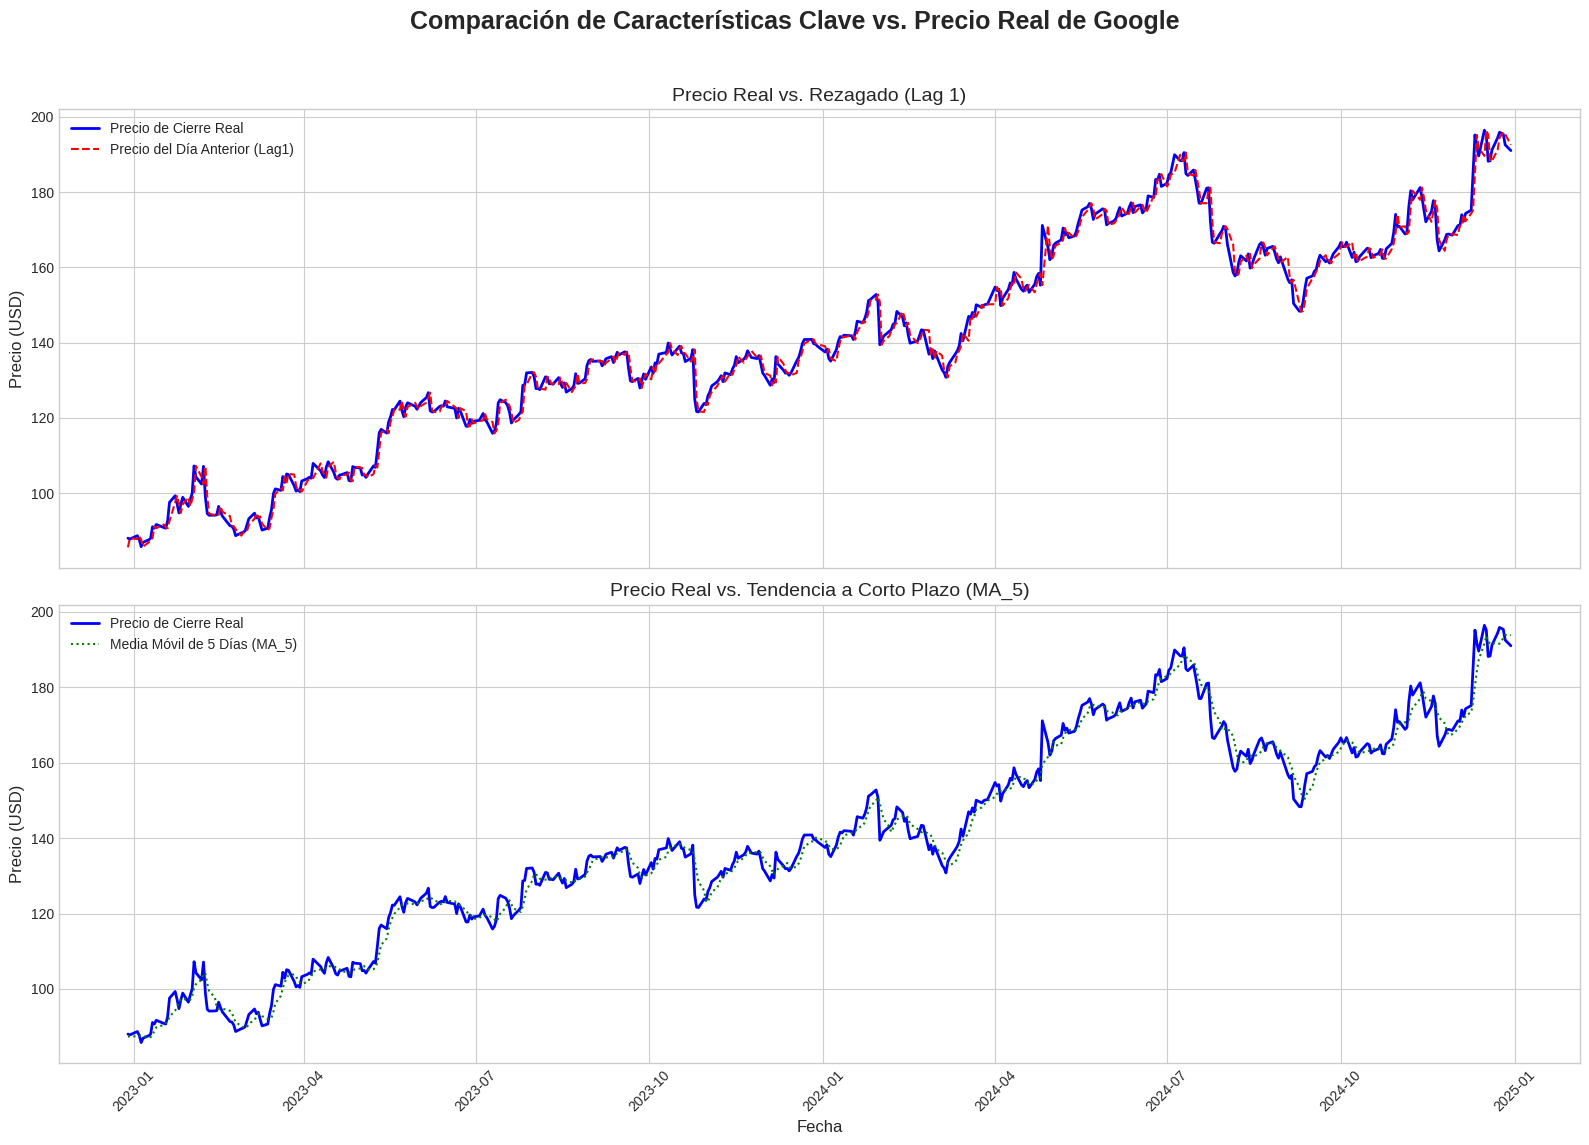

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Carga y Preparación de Datos ---
print("Cargando y preparando el dataset para la visualización...")
file_path = 'dataset_completo_google_amazon.csv'
df = pd.read_csv(file_path)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(by="Date").reset_index(drop=True)

# --- Crear las características que queremos visualizar ---
df['GOOGL_Close_Lag1'] = df['GOOGL_Close'].shift(1)
df['GOOGL_MA_5'] = df['GOOGL_Close'].rolling(window=5).mean()

# --- Seleccionar un período de tiempo para la visualización ---
df_plot = df.tail(500) # Aproximadamente 2 años de datos de trading

print("Generando el gráfico de visualización en subplots...")

# --- Creación de la Figura con 2 Subplots (uno encima del otro) ---
# `subplots(2, 1)` crea una cuadrícula de 2 filas y 1 columna.
# `sharex=True` asegura que ambos gráficos compartan el mismo eje X (la fecha), lo que facilita la comparación.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# --- Título General para toda la Figura ---
fig.suptitle('Comparación de Características Clave vs. Precio Real de Google', fontsize=18, fontweight='bold')

# --- Gráfico 1: Precio Real vs. Precio del Día Anterior (Lag1) ---
ax1.plot(df_plot['Date'], df_plot['GOOGL_Close'], label='Precio de Cierre Real', color='blue', linewidth=2)
ax1.plot(df_plot['Date'], df_plot['GOOGL_Close_Lag1'], label='Precio del Día Anterior (Lag1)', color='red', linestyle='--')
ax1.set_ylabel('Precio (USD)', fontsize=12)
ax1.set_title('Precio Real vs. Rezagado (Lag 1)', fontsize=14)
ax1.legend()
ax1.grid(True)

# --- Gráfico 2: Precio Real vs. Media Móvil de 5 Días ---
ax2.plot(df_plot['Date'], df_plot['GOOGL_Close'], label='Precio de Cierre Real', color='blue', linewidth=2)
ax2.plot(df_plot['Date'], df_plot['GOOGL_MA_5'], label='Media Móvil de 5 Días (MA_5)', color='green', linestyle=':')
ax2.set_ylabel('Precio (USD)', fontsize=12)
ax2.set_title('Precio Real vs. Tendencia a Corto Plazo (MA_5)', fontsize=14)
ax2.legend()
ax2.grid(True)

# --- Ajustes Finales ---
plt.xlabel('Fecha', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Ajustar para que el suptitle no se superponga

# Guardar y mostrar el gráfico
plt.savefig('google_main_features_subplots.png')
print("Gráfico guardado como 'google_main_features_subplots.png'")
plt.show()

Cargando y preparando el dataset para la visualización de Amazon...
Generando el gráfico de visualización en subplots para Amazon...
Gráfico guardado como 'amazon_main_features_subplots.png'


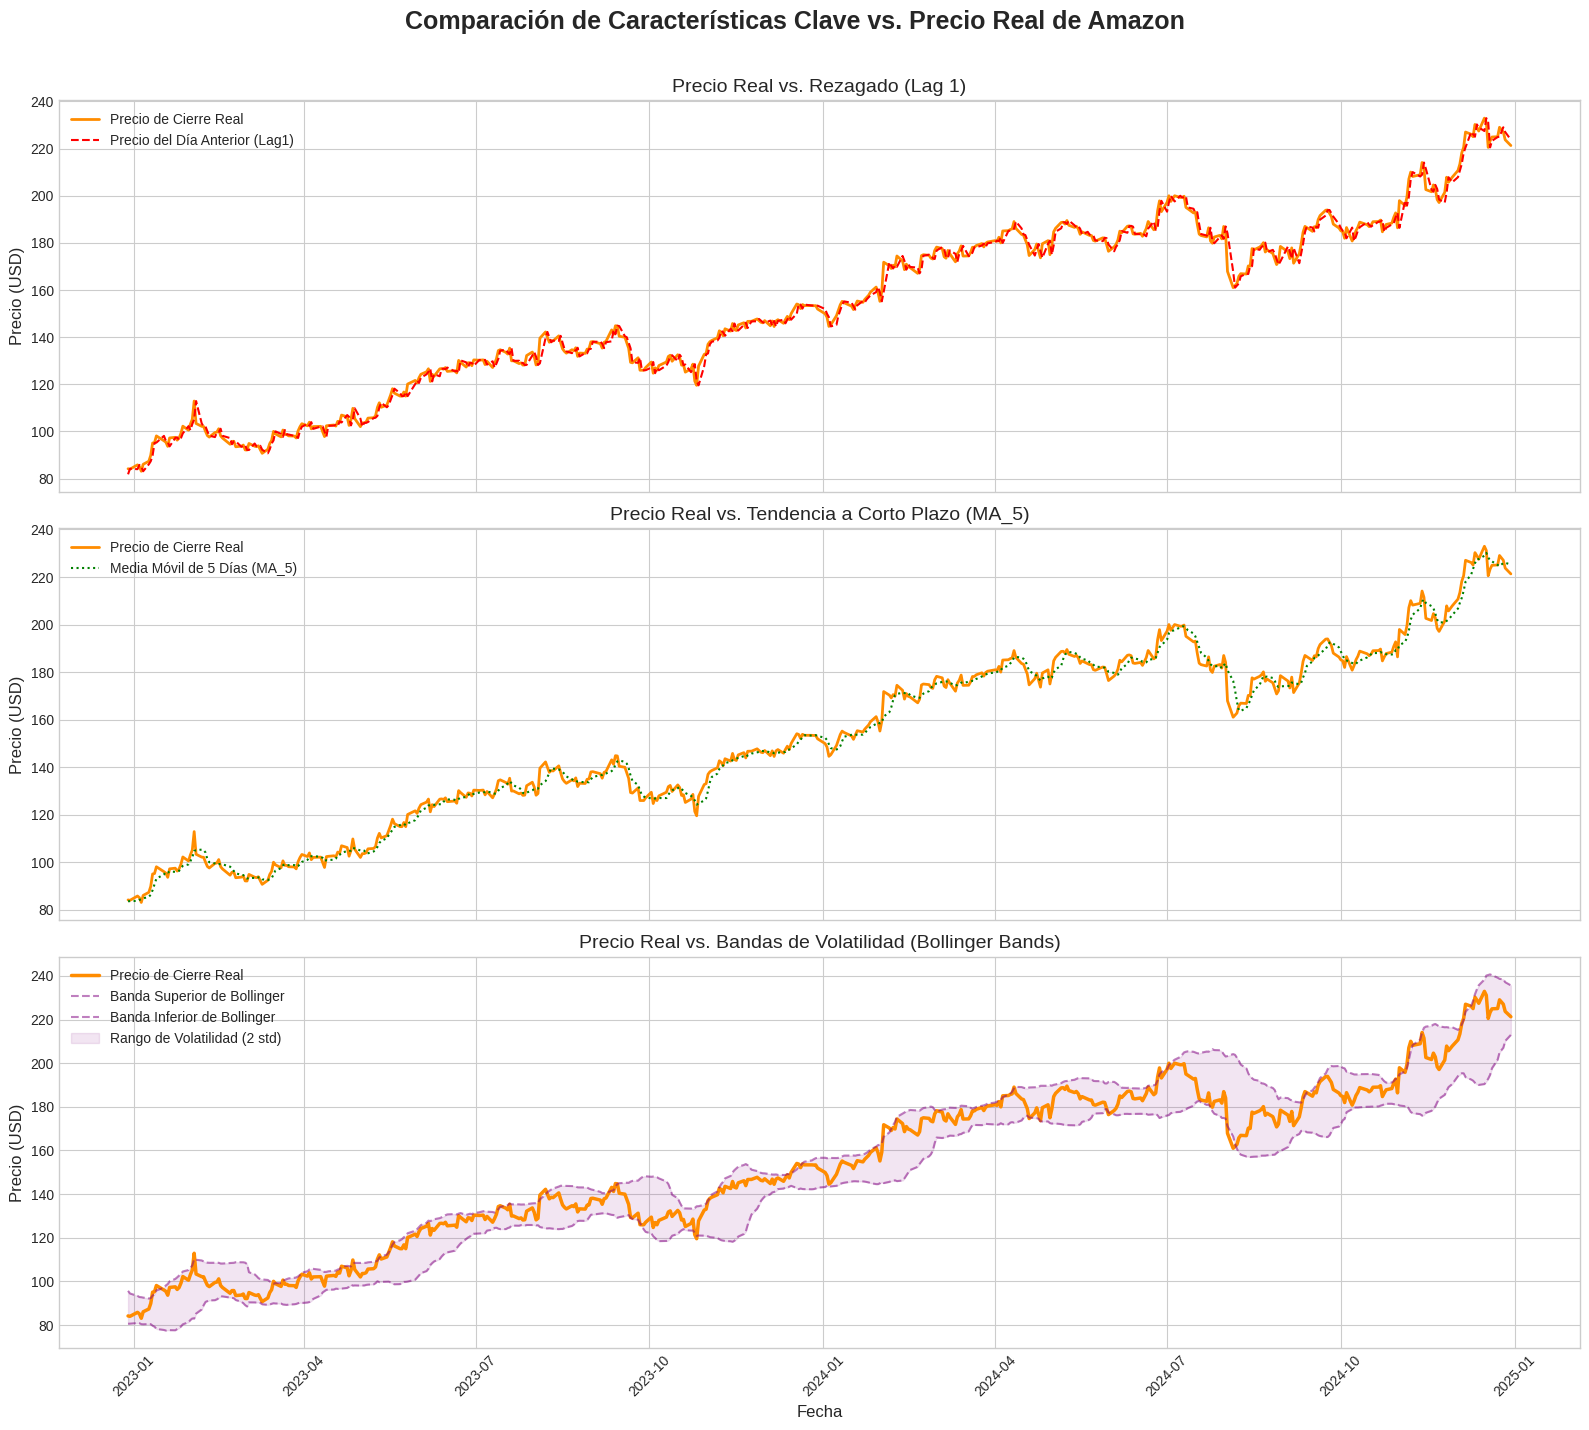

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Carga y Preparación de Datos ---
print("Cargando y preparando el dataset para la visualización de Amazon...")
file_path = 'dataset_completo_google_amazon.csv'
df = pd.read_csv(file_path)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(by="Date").reset_index(drop=True)

# --- 2. Crear las características que queremos visualizar ---
# Precio del día anterior (Lag 1)
df['AMZN_Close_Lag1'] = df['AMZN_Close'].shift(1)
# Media Móvil de 5 días
df['AMZN_MA_5'] = df['AMZN_Close'].rolling(window=5).mean()
# Bandas de Bollinger (necesitamos la inferior)
window_bb = 20
df['AMZN_BB_MA'] = df['AMZN_Close'].rolling(window=window_bb).mean()
df['AMZN_BB_std'] = df['AMZN_Close'].rolling(window=window_bb).std()
df['AMZN_BB_Upper'] = df['AMZN_BB_MA'] + (df['AMZN_BB_std'] * 2)
df['AMZN_BB_Lower'] = df['AMZN_BB_MA'] - (df['AMZN_BB_std'] * 2)

# --- 3. Seleccionar un período de tiempo para la visualización ---
df_plot = df.tail(500) # Aproximadamente 2 años de datos de trading

print("Generando el gráfico de visualización en subplots para Amazon...")

# --- 4. Creación de la Figura con 3 Subplots ---
# `subplots(3, 1)` crea una cuadrícula de 3 filas y 1 columna.
# `sharex=True` asegura que todos los gráficos compartan el mismo eje X (la fecha).
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 15), sharex=True)

# --- Título General para toda la Figura ---
fig.suptitle('Comparación de Características Clave vs. Precio Real de Amazon', fontsize=18, fontweight='bold')

# --- Gráfico 1: Precio Real vs. Precio del Día Anterior (Lag1) ---
ax1.plot(df_plot['Date'], df_plot['AMZN_Close'], label='Precio de Cierre Real', color='darkorange', linewidth=2)
ax1.plot(df_plot['Date'], df_plot['AMZN_Close_Lag1'], label='Precio del Día Anterior (Lag1)', color='red', linestyle='--')
ax1.set_ylabel('Precio (USD)', fontsize=12)
ax1.set_title('Precio Real vs. Rezagado (Lag 1)', fontsize=14)
ax1.legend()
ax1.grid(True)

# --- Gráfico 2: Precio Real vs. Media Móvil de 5 Días ---
ax2.plot(df_plot['Date'], df_plot['AMZN_Close'], label='Precio de Cierre Real', color='darkorange', linewidth=2)
ax2.plot(df_plot['Date'], df_plot['AMZN_MA_5'], label='Media Móvil de 5 Días (MA_5)', color='green', linestyle=':')
ax2.set_ylabel('Precio (USD)', fontsize=12)
ax2.set_title('Precio Real vs. Tendencia a Corto Plazo (MA_5)', fontsize=14)
ax2.legend()
ax2.grid(True)

# --- Gráfico 3: Precio Real vs. Bandas de Bollinger ---
ax3.plot(df_plot['Date'], df_plot['AMZN_Close'], label='Precio de Cierre Real', color='darkorange', linewidth=2.5)
ax3.plot(df_plot['Date'], df_plot['AMZN_BB_Upper'], label='Banda Superior de Bollinger', color='purple', linestyle='--', alpha=0.5)
ax3.plot(df_plot['Date'], df_plot['AMZN_BB_Lower'], label='Banda Inferior de Bollinger', color='purple', linestyle='--', alpha=0.5)
ax3.fill_between(df_plot['Date'], df_plot['AMZN_BB_Lower'], df_plot['AMZN_BB_Upper'], color='purple', alpha=0.1, label='Rango de Volatilidad (2 std)')
ax3.set_ylabel('Precio (USD)', fontsize=12)
ax3.set_title('Precio Real vs. Bandas de Volatilidad (Bollinger Bands)', fontsize=14)
ax3.legend()
ax3.grid(True)

# --- Ajustes Finales ---
plt.xlabel('Fecha', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Ajustar para que el suptitle no se superponga

# Guardar y mostrar el gráfico
plt.savefig('amazon_main_features_subplots.png')
print("Gráfico guardado como 'amazon_main_features_subplots.png'")
plt.show()

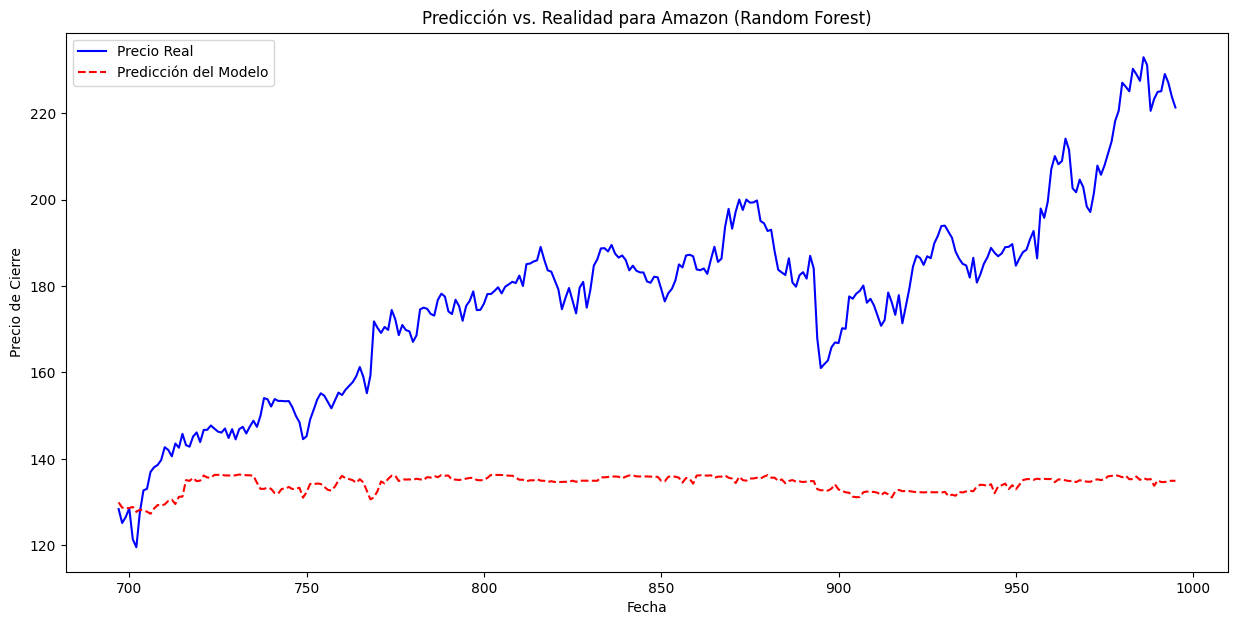

In [11]:
# Ejemplo para Amazon Random Forest
plt.figure(figsize=(15, 7))
plt.plot(y_test_amzn.index, y_test_amzn, label='Precio Real', color='blue')
plt.plot(y_test_amzn.index, y_pred_rf_amzn, label='Predicción del Modelo', color='red', linestyle='--')
plt.title('Predicción vs. Realidad para Amazon (Random Forest)')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre')
plt.legend()
plt.show()

Generando gráficos de Predicción vs. Realidad...
Gráfico de análisis de errores guardado como 'analisis_errores_prediccion_vs_realidad.png'


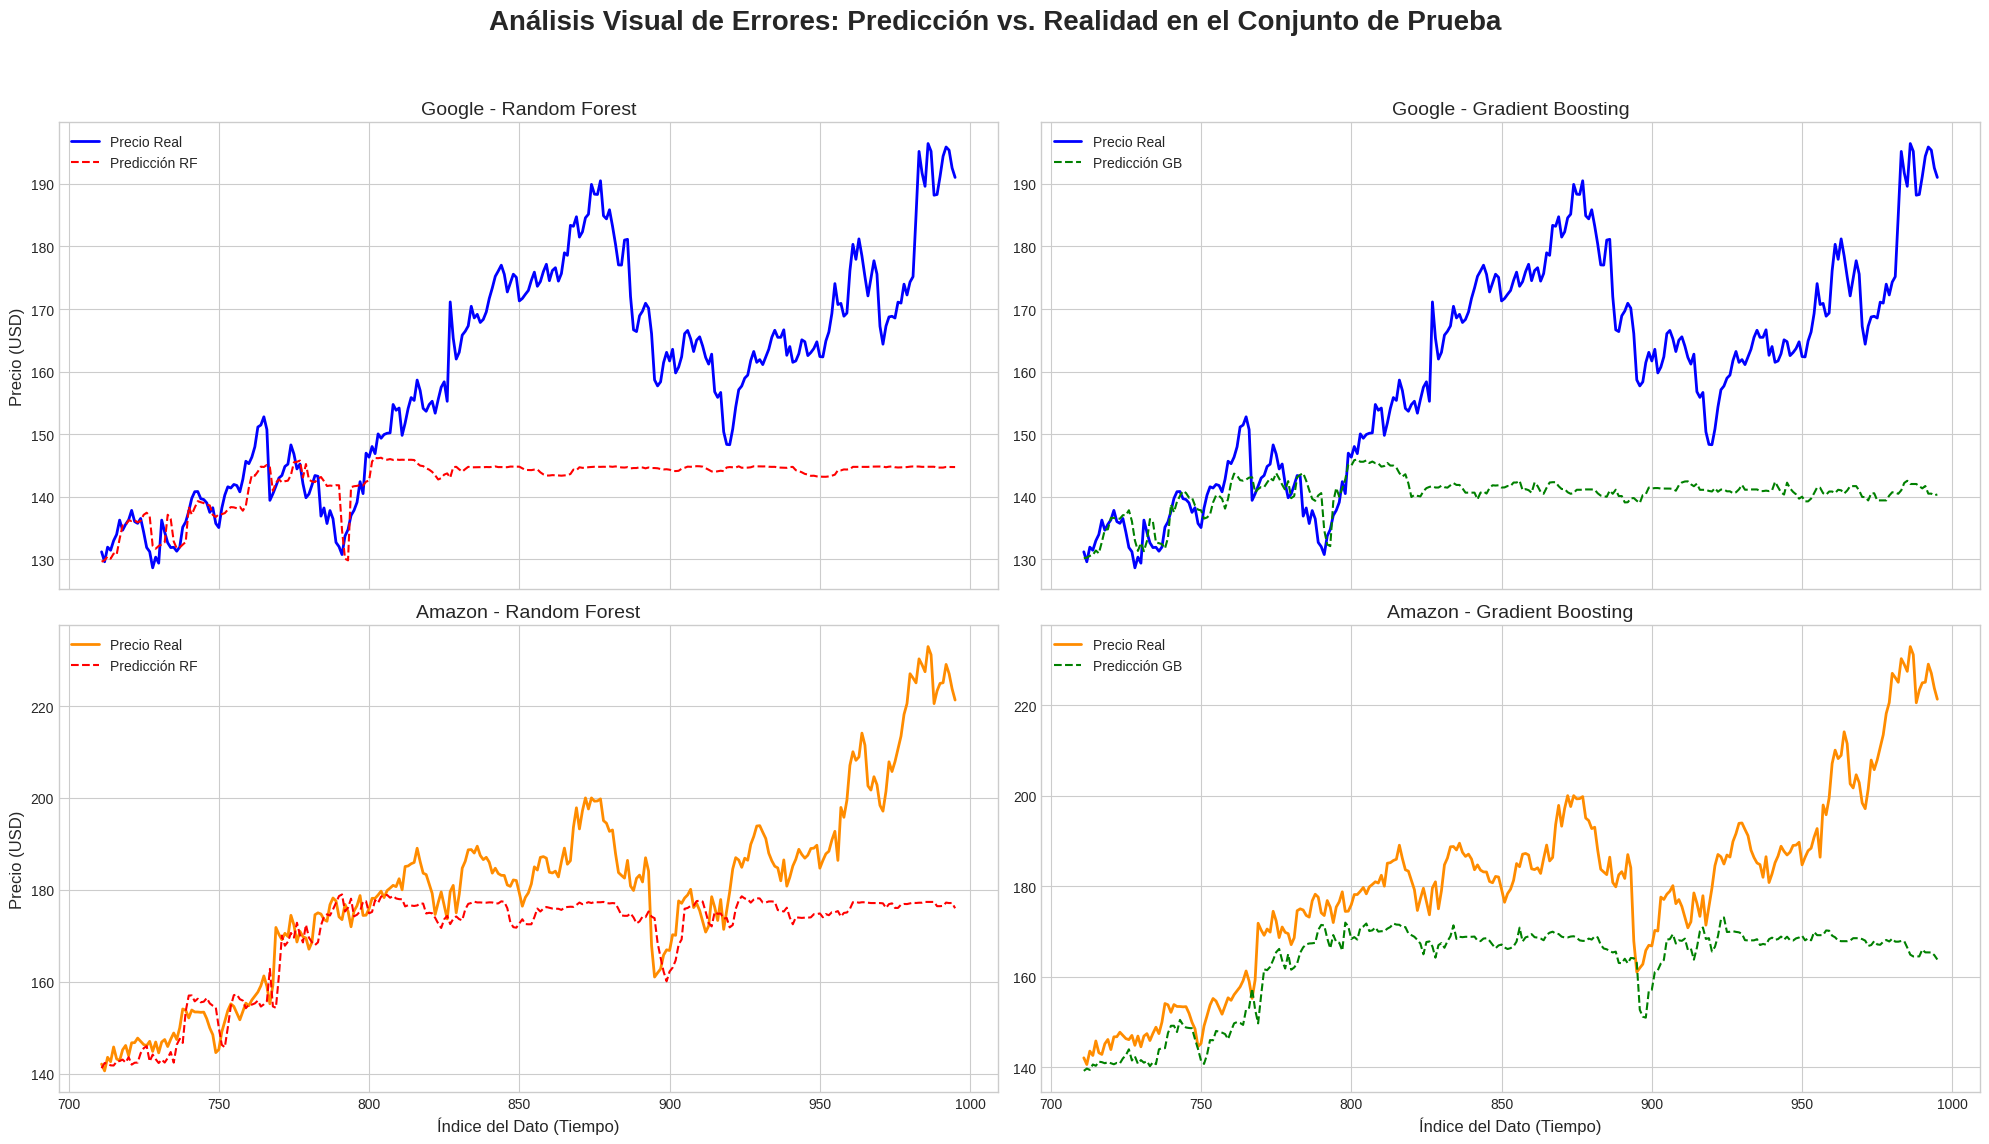

In [20]:
import matplotlib.pyplot as plt

# --- Asumimos que el código anterior ya se ha ejecutado ---
# y tenemos disponibles los siguientes objetos:
# y_test_googl, y_pred_rf_googl, y_pred_gb_googl
# y_test_amzn, y_pred_rf_amzn, y_pred_gb_amzn

print("Generando gráficos de Predicción vs. Realidad...")

# --- Creación de la Figura con 4 Subplots (2x2) ---
# `subplots(2, 2)` crea una cuadrícula de 2 filas y 2 columnas.
# `figsize` ajusta el tamaño total para que sea legible.
# `sharex=True` y `sharey=True` hacen que todos los gráficos compartan los mismos ejes para una comparación directa.
fig, axs = plt.subplots(2, 2, figsize=(20, 12), sharex=True, sharey=False) # sharey=False para que cada par tenga su propia escala Y

# --- Título General para toda la Figura ---
fig.suptitle('Análisis Visual de Errores: Predicción vs. Realidad en el Conjunto de Prueba', fontsize=20, fontweight='bold')

# --- 1. Gráfico: Google - Random Forest ---
axs[0, 0].plot(y_test_googl.index, y_test_googl, label='Precio Real', color='blue', linewidth=2)
axs[0, 0].plot(y_test_googl.index, y_pred_rf_googl, label='Predicción RF', color='red', linestyle='--')
axs[0, 0].set_title('Google - Random Forest', fontsize=14)
axs[0, 0].set_ylabel('Precio (USD)', fontsize=12)
axs[0, 0].legend()
axs[0, 0].grid(True)

# --- 2. Gráfico: Google - Gradient Boosting ---
axs[0, 1].plot(y_test_googl.index, y_test_googl, label='Precio Real', color='blue', linewidth=2)
axs[0, 1].plot(y_test_googl.index, y_pred_gb_googl, label='Predicción GB', color='green', linestyle='--')
axs[0, 1].set_title('Google - Gradient Boosting', fontsize=14)
axs[0, 1].legend()
axs[0, 1].grid(True)

# --- 3. Gráfico: Amazon - Random Forest ---
axs[1, 0].plot(y_test_amzn.index, y_test_amzn, label='Precio Real', color='darkorange', linewidth=2)
axs[1, 0].plot(y_test_amzn.index, y_pred_rf_amzn, label='Predicción RF', color='red', linestyle='--')
axs[1, 0].set_title('Amazon - Random Forest', fontsize=14)
axs[1, 0].set_ylabel('Precio (USD)', fontsize=12)
axs[1, 0].set_xlabel('Índice del Dato (Tiempo)', fontsize=12)
axs[1, 0].legend()
axs[1, 0].grid(True)

# --- 4. Gráfico: Amazon - Gradient Boosting ---
axs[1, 1].plot(y_test_amzn.index, y_test_amzn, label='Precio Real', color='darkorange', linewidth=2)
axs[1, 1].plot(y_test_amzn.index, y_pred_gb_amzn, label='Predicción GB', color='green', linestyle='--')
axs[1, 1].set_title('Amazon - Gradient Boosting', fontsize=14)
axs[1, 1].set_xlabel('Índice del Dato (Tiempo)', fontsize=12)
axs[1, 1].legend()
axs[1, 1].grid(True)

# --- Ajustes Finales ---
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar para que el suptitle no se superponga

# Guardar y mostrar el gráfico
plt.savefig('analisis_errores_prediccion_vs_realidad.png')
print("Gráfico de análisis de errores guardado como 'analisis_errores_prediccion_vs_realidad.png'")
plt.show()

### Interpretaciones Financieras y Estadísticas

## Interpretaciones Financieras y Estadísticas

### Rendimiento de los Modelos Predictivos

Para evaluar la incidencia de los datos históricos de precios en la precisión de los modelos supervisados, se utilizaron dos métricas clave: el Error Cuadrático Medio (MSE) y el Coeficiente de Determinación (R2).

*   **Error Cuadrático Medio (MSE):** Mide el promedio de los cuadrados de los errores, es decir, la diferencia entre los valores predichos por el modelo y los valores reales. Un MSE más bajo indica un mejor ajuste del modelo a los datos.
*   **Coeficiente de Determinación (R2):** Representa la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes. Un valor de R2 cercano a 1 indica que el modelo explica una gran parte de la variabilidad de la variable objetivo, lo que sugiere una alta precisión predictiva.



**Análisis:**

*   **Altos valores de R2:** Tanto para Google como para Amazon, ambos modelos (Random Forest y Gradient Boosting) muestran valores de R2 extremadamente altos (superiores a 0.989). Esto indica que los modelos son capaces de explicar más del 98.9% de la variabilidad en los precios de cierre de las acciones. Esto sugiere que los datos históricos de precios, junto con las variables macroeconómicas y técnicas incluidas, son predictores muy fuertes de los precios futuros de las acciones.
*   **Bajos valores de MSE:** Los valores de MSE son relativamente bajos, lo que refuerza la idea de que las predicciones de los modelos están muy cerca de los precios reales. Un MSE de 6.8865 para GOOGL_RF, por ejemplo, significa que, en promedio, el cuadrado de la diferencia entre el precio real y el predicho es 6.8865. En el contexto de precios de acciones que pueden variar significativamente, estos valores son indicativos de una buena precisión.














         |






